In [ ]:
!pip install vaderSentiment

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 8.0 MB/s eta 0:00:00


In [ ]:
!pip install gensim

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import spacy
from spacy import displacy
from spacy import tokenizer
import re
import nltk
from nltk.tokenize import word_tokenize
from nltk.stem import PorterStemmer, WordNetLemmatizer
from nltk.corpus import stopwords
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
import gensim
import gensim.corpora as corpora
from gensim.models.coherencemodel import CoherenceModel
from gensim.models import LsiModel, TfidfModel
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.metrics import accuracy_score, classification_report

In [ ]:
# set plot options
plt.rcParams['figure.figsize'] = (12, 8)
default_plot_colour = "#00bfbf"



In [ ]:
from google.colab import files
uploaded = files.upload()

Saving fake_news_data.csv to fake_news_data.csv


In [ ]:
import pandas as pd

file_name = list(uploaded.keys())[0]   # get actual file name
data = pd.read_csv(file_name)

data.head()

,title,text,date,fake_or_factual
0,HOLLYWEIRD LIB SUSAN SARANDON Compares Muslim ...,There are two small problems with your analogy...,"Dec 30, 2015",Fake News
1,Elijah Cummings Called Trump Out To His Face ...,Buried in Trump s bonkers interview with New Y...,"April 6, 2017",Fake News
2,Hillary Clinton Says Half Her Cabinet Will Be...,"Women make up over 50 percent of this country,...","April 26, 2016",Fake News
3,Russian bombing of U.S.-backed forces being di...,WASHINGTON (Reuters) - U.S. Defense Secretary ...,"September 18, 2017",Factual News
4,Britain says window to restore Northern Irelan...,BELFAST (Reuters) - Northern Ireland s politic...,"September 4, 2017",Factual News


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 198 entries, 0 to 197
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   title            198 non-null    object
 1   text             198 non-null    object
 2   date             198 non-null    object
 3   fake_or_factual  198 non-null    object
dtypes: object(4)
memory usage: 6.3+ KB


Text(0.5, 1.0, 'Count of Article Classification')

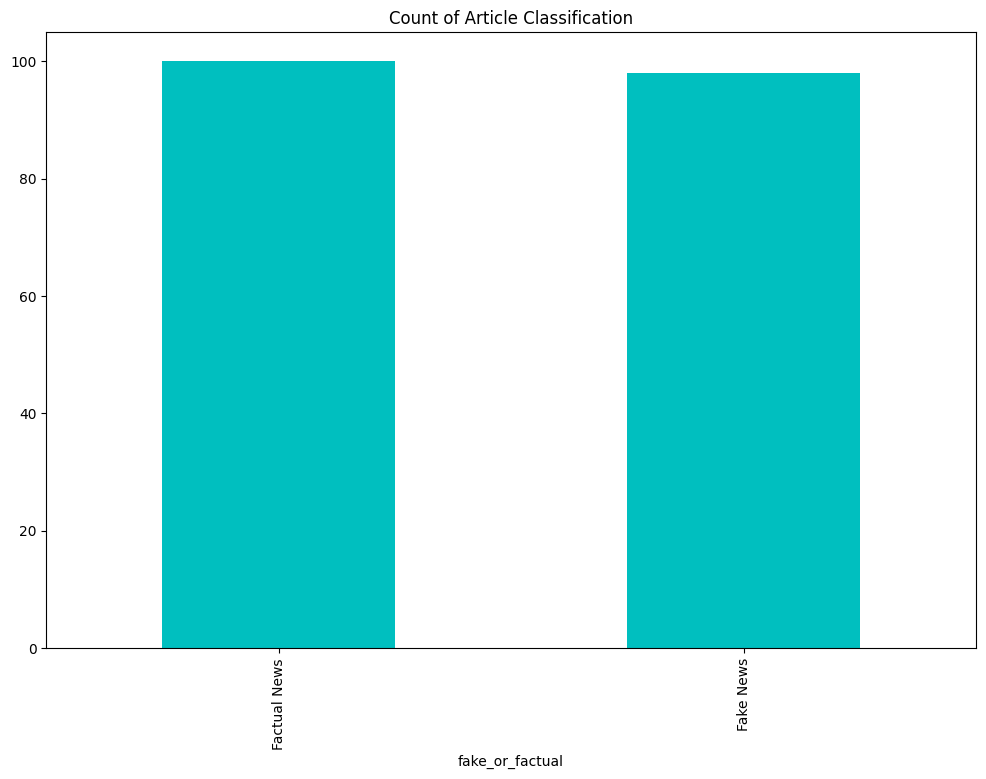

In [ ]:
data['fake_or_factual'].value_counts().plot(kind='bar', color=default_plot_colour)
plt.title("Count of Article Classification")

In [ ]:
#Exploring our data
#Tagging
# POS Tagging

nlp = spacy.load('en_core_web_sm')



In [ ]:
fake_news = data[data['fake_or_factual'] == "Fake News"]
fact_news = data[data['fake_or_factual'] == "Factual News"]



In [ ]:
fake_spacydocs = list(nlp.pipe(fake_news['text']))
fact_spacydoc = list(nlp.pipe(fact_news['text']))



In [ ]:
def extract_token_tags(doc: spacy.tokens.doc.Doc):
    return [(i.text, i.ent_type_, i.pos_) for i in doc]



In [ ]:
fake_tagsdf = []
columns = ['token', 'ner_tag', 'pos_tag']



In [ ]:
for ix, doc in enumerate(fake_spacydocs):
    tags = extract_token_tags(doc)
    tags = pd.DataFrame(tags)
    tags.columns = columns
    fake_tagsdf.append(tags)



In [ ]:
fake_tagsdf = pd.concat(fake_tagsdf)



In [ ]:
fact_tagsdf = []

for ix, doc in enumerate(fact_spacydoc):
    tags = extract_token_tags(doc)
    tags = pd.DataFrame(tags)
    tags.columns = columns
    fact_tagsdf.append(tags)



In [ ]:
fact_tagsdf = pd.concat(fact_tagsdf)



In [ ]:
fake_tagsdf.head()

,token,ner_tag,pos_tag
0,There,,PRON
1,are,,VERB
2,two,CARDINAL,NUM
3,small,,ADJ
4,problems,,NOUN


In [ ]:
pos_counts_fake = fake_tagsdf.groupby(['token', 'pos_tag']).size().reset_index(name="counts").sort_values(by="counts")
pos_counts_fake.head(10)

,token,pos_tag,counts
8025,yourself,PRON,1
6,#,NOUN,1
5,#,ADV,1
40,.,PROPN,1
39,.,NOUN,1
38,-incrementally,ADV,1
37,-H,PROPN,1
8002,writing,VERB,1
8001,writes,VERB,1
8000,writer,NOUN,1


In [ ]:
pos_counts_fact = fact_tagsdf.groupby(['token', 'pos_tag']).size().reset_index(name="counts").sort_values(by="counts")
pos_counts_fact.head(10)

,token,pos_tag,counts
3430,exodus,NOUN,1
3429,exited,VERB,1
3427,exists,VERB,1
3424,exercising,VERB,1
3421,exercise,VERB,1
3419,exemption,NOUN,1
3415,executing,VERB,1
3414,executes,VERB,1
3413,exclusively,ADV,1
3412,exchanged,VERB,1


In [ ]:
pos_counts_fake.groupby('pos_tag')['token'].count().sort_values(ascending=False).head(10)

,token
pos_tag,
NOUN,2586
VERB,1817
PROPN,1672
ADJ,882
ADV,413
NUM,221
PRON,96
ADP,89
AUX,62


In [ ]:
pos_counts_fact.groupby('pos_tag')['token'].count().sort_values(ascending=False).head(10)

,token
pos_tag,
NOUN,2179
VERB,1539
PROPN,1379
ADJ,747
ADV,263
NUM,205
PRON,79
ADP,70
AUX,43


In [ ]:
pos_counts_fake[pos_counts_fake.pos_tag == "NOUN"][:15]

,token,pos_tag,counts
6,#,NOUN,1
39,.,NOUN,1
8000,writer,NOUN,1
7156,standard,NOUN,1
8016,yen,NOUN,1
60,102Please,NOUN,1
85,"18,589.69",NOUN,1
6673,retweets,NOUN,1
6671,retweet,NOUN,1
6666,retreat,NOUN,1


In [ ]:
pos_counts_fact[pos_counts_fact.pos_tag == "NOUN"][:15]

,token,pos_tag,counts
3430,exodus,NOUN,1
3419,exemption,NOUN,1
3409,exceptions,NOUN,1
6616,wrong,NOUN,1
6612,writers,NOUN,1
20,.,NOUN,1
6645,’s,NOUN,1
6595,worker,NOUN,1
6586,woman,NOUN,1
6584,witnesses,NOUN,1


In [ ]:
#Extracting named entities

In [ ]:
top_entities_fake = fake_tagsdf[fake_tagsdf['ner_tag'] != ""].groupby(['token', 'ner_tag']).size().reset_index(name='counts').sort_values(by='counts', ascending=False)

In [ ]:
top_entities_fact = fact_tagsdf[fact_tagsdf['ner_tag'] != ""].groupby(['token', 'ner_tag']).size().reset_index(name='counts').sort_values(by='counts', ascending=False)

In [ ]:
ner_palette = {
    'ORG': sns.color_palette("Set2").as_hex()[0],
    'GPE': sns.color_palette("Set2").as_hex()[1],
    'NORP': sns.color_palette("Set2").as_hex()[2],
    'PERSON': sns.color_palette("Set2").as_hex()[3],
    'DATE': sns.color_palette("Set2").as_hex()[4],
    'CARDINAL': sns.color_palette("Set2").as_hex()[5],
    'PERCENT': sns.color_palette("Set2").as_hex()[6]
}



[Text(0.5, 1.0, 'Most Common Named Entities in Fake News')]

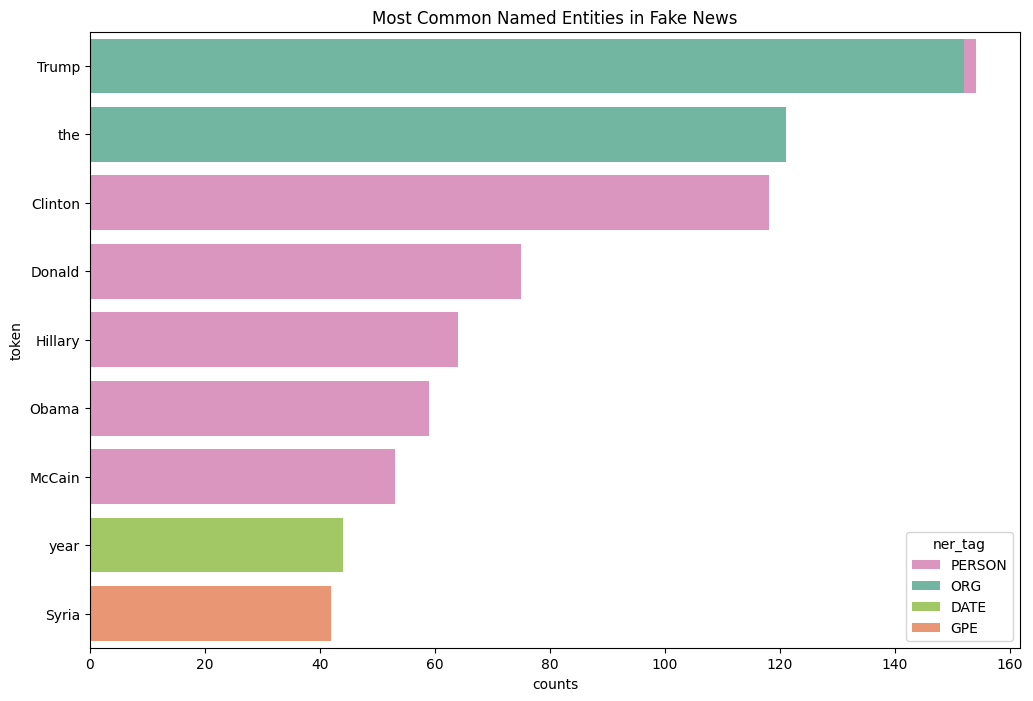

In [ ]:
sns.barplot(
    x='counts',
    y='token',
    hue='ner_tag',
    palette=ner_palette,
    data=top_entities_fake[:10],
    orient='h',
    dodge=False
).set(title="Most Common Named Entities in Fake News")

[Text(0.5, 1.0, 'Most Common Named Entities in Factual News')]

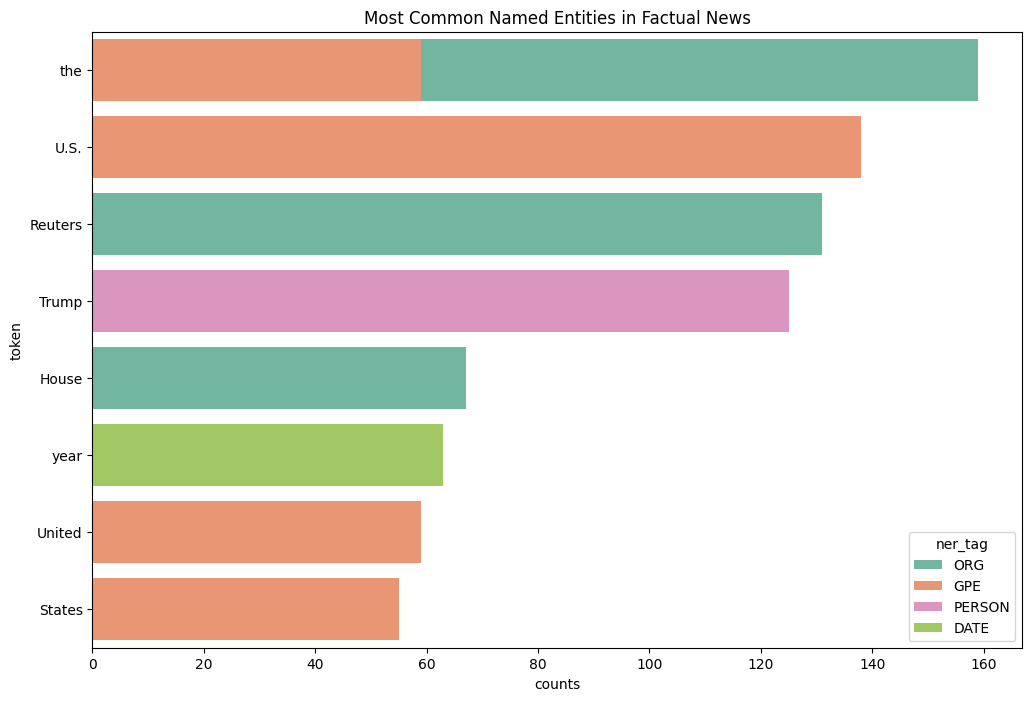

In [ ]:
sns.barplot(
    x='counts',
    y='token',
    hue='ner_tag',
    palette=ner_palette,
    data=top_entities_fact[:10],
    orient='h',
    dodge=False
).set(title="Most Common Named Entities in Factual News")

In [ ]:
#Pre-Processing the Text

In [ ]:
data.head()

,title,text,date,fake_or_factual
0,HOLLYWEIRD LIB SUSAN SARANDON Compares Muslim ...,There are two small problems with your analogy...,"Dec 30, 2015",Fake News
1,Elijah Cummings Called Trump Out To His Face ...,Buried in Trump s bonkers interview with New Y...,"April 6, 2017",Fake News
2,Hillary Clinton Says Half Her Cabinet Will Be...,"Women make up over 50 percent of this country,...","April 26, 2016",Fake News
3,Russian bombing of U.S.-backed forces being di...,WASHINGTON (Reuters) - U.S. Defense Secretary ...,"September 18, 2017",Factual News
4,Britain says window to restore Northern Irelan...,BELFAST (Reuters) - Northern Ireland s politic...,"September 4, 2017",Factual News


In [ ]:
data['text_clean'] = data.apply(lambda x: re.sub(r"[^A-Za-z\s]", "", x['text']), axis=1)



In [ ]:
data['text_clean'] = data['text_clean'].str.lower()



In [ ]:
data['text_clean'] = data.apply(lambda x: re.sub(r"[^\w\s]", "", x['text_clean']), axis=1)


In [ ]:
import nltk
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [ ]:
from nltk.corpus import stopwords

en_stopwords = stopwords.words('english')
print(en_stopwords)

['a', 'about', 'above', 'after', 'again', 'against', 'ain', 'all', 'am', 'an', 'and', 'any', 'are', 'aren', "aren't", 'as', 'at', 'be', 'because', 'been', 'before', 'being', 'below', 'between', 'both', 'but', 'by', 'can', 'couldn', "couldn't", 'd', 'did', 'didn', "didn't", 'do', 'does', 'doesn', "doesn't", 'doing', 'don', "don't", 'down', 'during', 'each', 'few', 'for', 'from', 'further', 'had', 'hadn', "hadn't", 'has', 'hasn', "hasn't", 'have', 'haven', "haven't", 'having', 'he', "he'd", "he'll", 'her', 'here', 'hers', 'herself', "he's", 'him', 'himself', 'his', 'how', 'i', "i'd", 'if', "i'll", "i'm", 'in', 'into', 'is', 'isn', "isn't", 'it', "it'd", "it'll", "it's", 'its', 'itself', "i've", 'just', 'll', 'm', 'ma', 'me', 'mightn', "mightn't", 'more', 'most', 'mustn', "mustn't", 'my', 'myself', 'needn', "needn't", 'no', 'nor', 'not', 'now', 'o', 'of', 'off', 'on', 'once', 'only', 'or', 'other', 'our', 'ours', 'ourselves', 'out', 'over', 'own', 're', 's', 'same', 'shan', "shan't", 'she

In [ ]:
data['text_clean'] = data['text_clean'].apply(
    lambda x: " ".join([word for word in x.split() if word not in en_stopwords])
)

In [ ]:
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...


True

In [ ]:
lemmatizer = WordNetLemmatizer()
data['text_clean'] = data['text_clean'].apply(
    lambda tokens: [lemmatizer.lemmatize(token) for token in tokens]
)

tokens_clean = sum(data['text_clean'], [])

unigrams = pd.Series(nltk.ngrams(tokens_clean, 1)).value_counts().reset_index()[:10]
print(unigrams)

           index  count
0       (trump,)    584
1        (said,)    580
2           (u,)    278
3       (state,)    275
4   (president,)    259
5       (would,)    226
6         (one,)    162
7     (clinton,)    142
8        (year,)    142
9  (republican,)    137


/tmp/ipykernel_526/2349300824.py:3: UserWarning: 
The palette list has fewer values (1) than needed (10) and will cycle, which may produce an uninterpretable plot.
  sns.barplot(


[Text(0.5, 1.0, 'Most Common Unigrams After Preprocessing')]

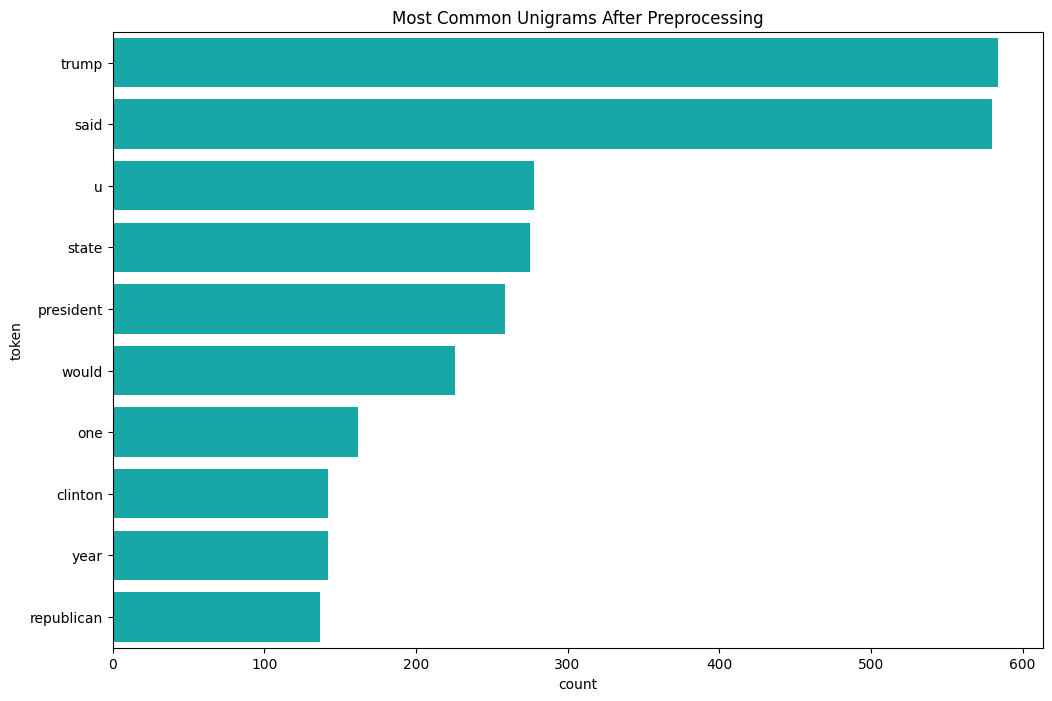

In [ ]:
unigrams['token'] = unigrams['index'].apply(lambda x: x[0])

sns.barplot(
    x="count",
    y="token",
    data=unigrams,
    orient="h",
    palette=[default_plot_colour],
    hue="token",
    legend=False
).set(title="Most Common Unigrams After Preprocessing")

In [ ]:
bigrams = pd.Series(nltk.ngrams(tokens_clean, 2)).value_counts().reset_index()[:10]
print(bigrams)

                     index  count
0          (donald, trump)    113
1          (united, state)     84
2           (white, house)     74
3      (president, donald)     47
4       (hillary, clinton)     39
5              (new, york)     34
6    (washington, reuters)     32
7         (supreme, court)     30
8             (image, via)     29
9  (trump, administration)     26


In [ ]:
#Sentimental Analysis
vader_sentiment = SentimentIntensityAnalyzer()



In [ ]:
data['vader_sentiment_score'] = data['text'].apply(
    lambda x: vader_sentiment.polarity_scores(x)['compound']
)



In [ ]:
data.head()

,title,text,date,fake_or_factual,text_clean,vader_sentiment_score
0,HOLLYWEIRD LIB SUSAN SARANDON Compares Muslim ...,There are two small problems with your analogy...,"Dec 30, 2015",Fake News,"[two, small, problem, analogy, susan, jesus, m...",-0.3660
1,Elijah Cummings Called Trump Out To His Face ...,Buried in Trump s bonkers interview with New Y...,"April 6, 2017",Fake News,"[buried, trump, bonkers, interview, new, york,...",-0.8197
2,Hillary Clinton Says Half Her Cabinet Will Be...,"Women make up over 50 percent of this country,...","April 26, 2016",Fake News,"[woman, make, percent, country, grossly, under...",0.9779
3,Russian bombing of U.S.-backed forces being di...,WASHINGTON (Reuters) - U.S. Defense Secretary ...,"September 18, 2017",Factual News,"[washington, reuters, u, defense, secretary, j...",-0.3400
4,Britain says window to restore Northern Irelan...,BELFAST (Reuters) - Northern Ireland s politic...,"September 4, 2017",Factual News,"[belfast, reuters, northern, ireland, politica...",0.8590


In [ ]:
bins = [-1, -0.1, 0.1, 1]
names = ['negative', 'neutral', 'positive']



In [ ]:
data['vader_sentiment_label'] = pd.cut(data['vader_sentiment_score'], bins, labels=names)



In [ ]:
data.head()

,title,text,date,fake_or_factual,text_clean,vader_sentiment_score,vader_sentiment_label
0,HOLLYWEIRD LIB SUSAN SARANDON Compares Muslim ...,There are two small problems with your analogy...,"Dec 30, 2015",Fake News,"[two, small, problem, analogy, susan, jesus, m...",-0.3660,negative
1,Elijah Cummings Called Trump Out To His Face ...,Buried in Trump s bonkers interview with New Y...,"April 6, 2017",Fake News,"[buried, trump, bonkers, interview, new, york,...",-0.8197,negative
2,Hillary Clinton Says Half Her Cabinet Will Be...,"Women make up over 50 percent of this country,...","April 26, 2016",Fake News,"[woman, make, percent, country, grossly, under...",0.9779,positive
3,Russian bombing of U.S.-backed forces being di...,WASHINGTON (Reuters) - U.S. Defense Secretary ...,"September 18, 2017",Factual News,"[washington, reuters, u, defense, secretary, j...",-0.3400,negative
4,Britain says window to restore Northern Irelan...,BELFAST (Reuters) - Northern Ireland s politic...,"September 4, 2017",Factual News,"[belfast, reuters, northern, ireland, politica...",0.8590,positive


<Axes: xlabel='vader_sentiment_label'>

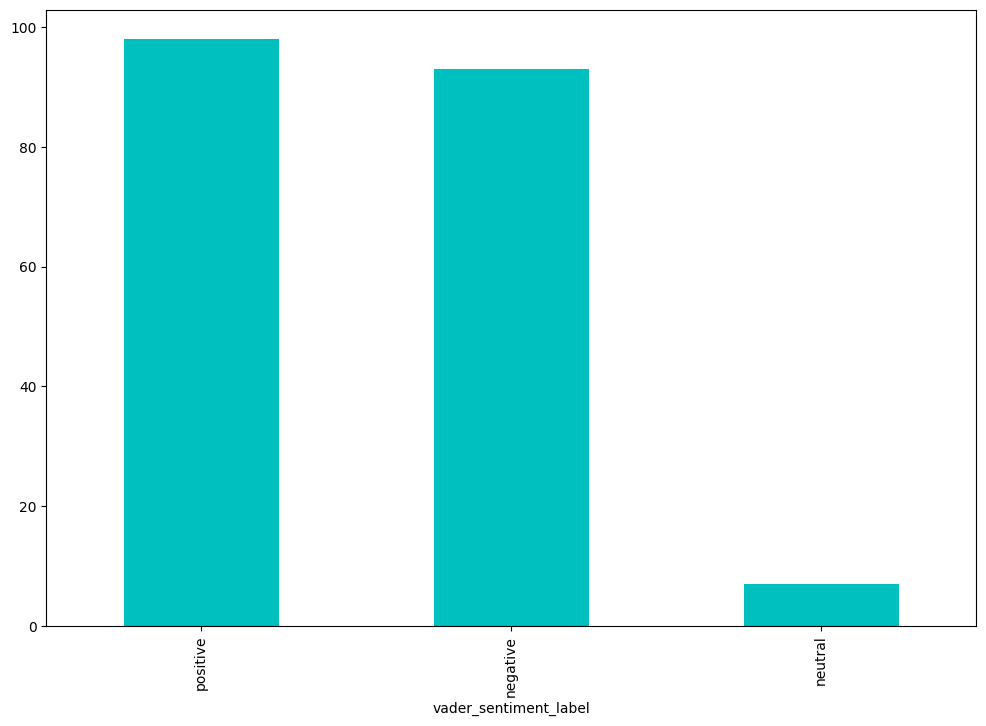

In [ ]:
data['vader_sentiment_label'].value_counts().plot.bar(color=default_plot_colour)

/tmp/ipykernel_526/2500496183.py:1: UserWarning: The palette list has more values (6) than needed (3), which may not be intended.
  sns.countplot(


[Text(0.5, 1.0, 'Sentiment by News Type')]

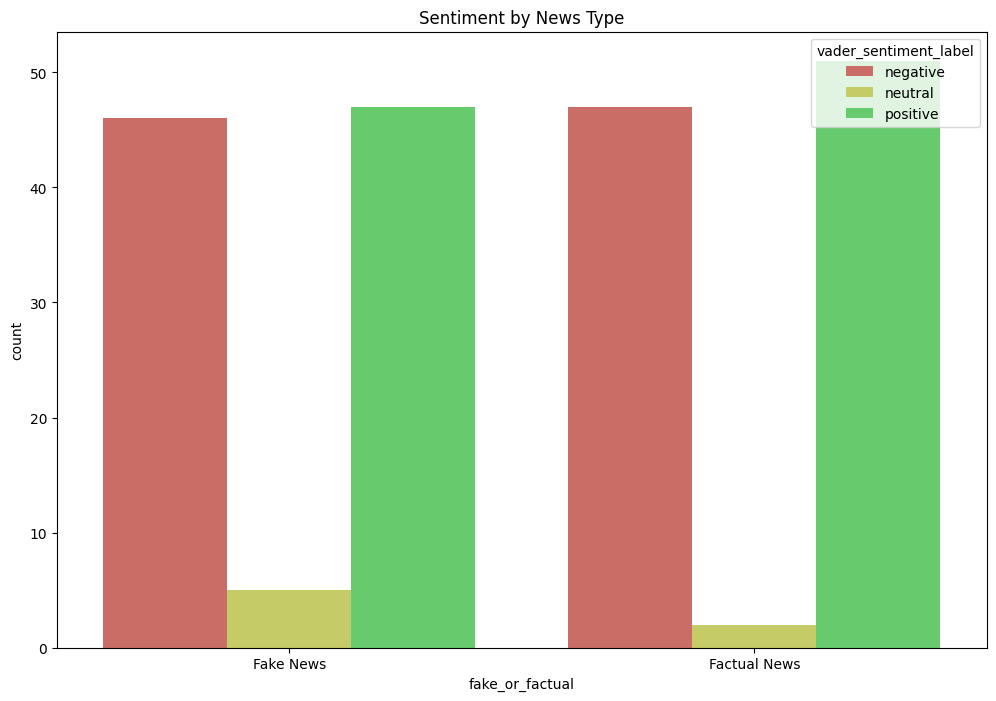

In [ ]:
sns.countplot(
    x='fake_or_factual',
    hue='vader_sentiment_label',
    palette=sns.color_palette("hls"),
    data=data
).set(title="Sentiment by News Type")

In [ ]:
#Topic Modelling
fake_news_text = data[data['fake_or_factual'] == "Fake News"]['text_clean'].reset_index(drop=True)



In [ ]:
dictionary_fake = corpora.Dictionary(fake_news_text)


In [ ]:

doc_term_fake = [dictionary_fake.doc2bow(text) for text in fake_news_text]



In [ ]:
coherence_values = []
model_list = []

min_topics = 2
max_topics = 11

for num_topics_i in range(min_topics, max_topics + 1):
    model = gensim.models.LdaModel(
        doc_term_fake,
        num_topics=num_topics_i,
        id2word=dictionary_fake
    )
    model_list.append(model)

    coherence_model = CoherenceModel(
        model=model,
        texts=fake_news_text,
        dictionary=dictionary_fake,
        coherence='c_v'
    )
    coherence_values.append(coherence_model.get_coherence())



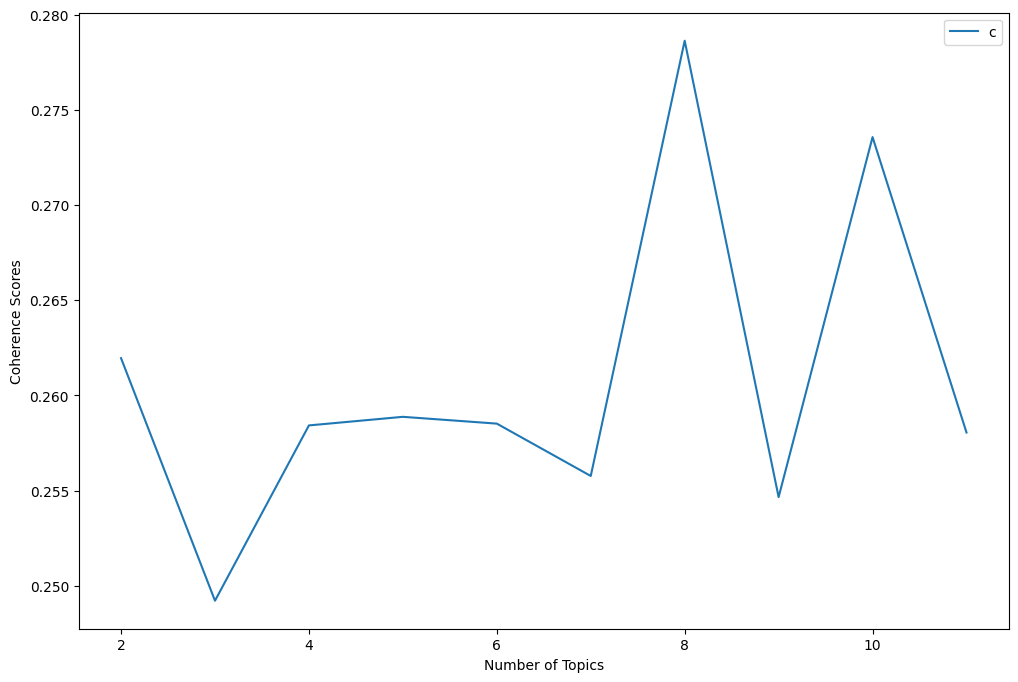

In [ ]:
plt.plot(range(min_topics, max_topics + 1), coherence_values)
plt.xlabel("Number of Topics")
plt.ylabel("Coherence Scores")
plt.legend(("coherence_values"), loc='best')
plt.show()

In [ ]:
num_topics_lda = 7

lda_model = gensim.models.LdaModel(
    corpus=doc_term_fake,
    id2word=dictionary_fake,
    num_topics=num_topics_lda
)



In [ ]:
lda_model.print_topics(num_topics=num_topics_lda, num_words=10)

[(0,
  '0.006*"trump" + 0.005*"u" + 0.004*"obama" + 0.004*"said" + 0.004*"state" + 0.004*"president" + 0.004*"clinton" + 0.003*"hillary" + 0.003*"year" + 0.003*"one"'),
 (1,
  '0.012*"trump" + 0.005*"said" + 0.005*"president" + 0.004*"state" + 0.004*"people" + 0.003*"would" + 0.003*"u" + 0.003*"time" + 0.003*"woman" + 0.003*"bannon"'),
 (2,
  '0.011*"trump" + 0.005*"president" + 0.004*"clinton" + 0.004*"one" + 0.004*"said" + 0.004*"would" + 0.004*"republican" + 0.003*"u" + 0.003*"time" + 0.003*"white"'),
 (3,
  '0.014*"trump" + 0.007*"president" + 0.005*"republican" + 0.005*"said" + 0.005*"one" + 0.004*"time" + 0.004*"u" + 0.004*"donald" + 0.004*"clinton" + 0.003*"state"'),
 (4,
  '0.012*"trump" + 0.005*"would" + 0.004*"one" + 0.004*"said" + 0.004*"woman" + 0.004*"clinton" + 0.003*"president" + 0.003*"state" + 0.003*"time" + 0.003*"u"'),
 (5,
  '0.013*"trump" + 0.007*"said" + 0.005*"state" + 0.004*"clinton" + 0.004*"time" + 0.004*"u" + 0.003*"would" + 0.003*"one" + 0.003*"obama" + 0.00

In [ ]:
def tfidf_corpus(doc_term_matrix):
    tfidf = TfidfModel(corpus=doc_term_matrix, normalize=True)
    corpus_tfidf = tfidf[doc_term_matrix]
    return corpus_tfidf




In [ ]:
def get_coherence_scores(corpus, dictionary, text, min_topics, max_topics):
    coherence_values = []
    model_list = []

    for num_topics_i in range(min_topics, max_topics + 1):
        model = LsiModel(corpus, num_topics=num_topics_i, id2word=dictionary)
        model_list.append(model)

        coherence_model = CoherenceModel(
            model=model,
            texts=text,
            dictionary=dictionary,
            coherence='c_v'
        )
        coherence_values.append(coherence_model.get_coherence())

    plt.plot(range(min_topics, max_topics + 1), coherence_values)
    plt.xlabel("Number of Topics")
    plt.ylabel("Coherence score")
    plt.legend(("coherence_values"), loc='best')
    plt.show()




In [ ]:
corpus_tfidf_fake = tfidf_corpus(doc_term_fake)



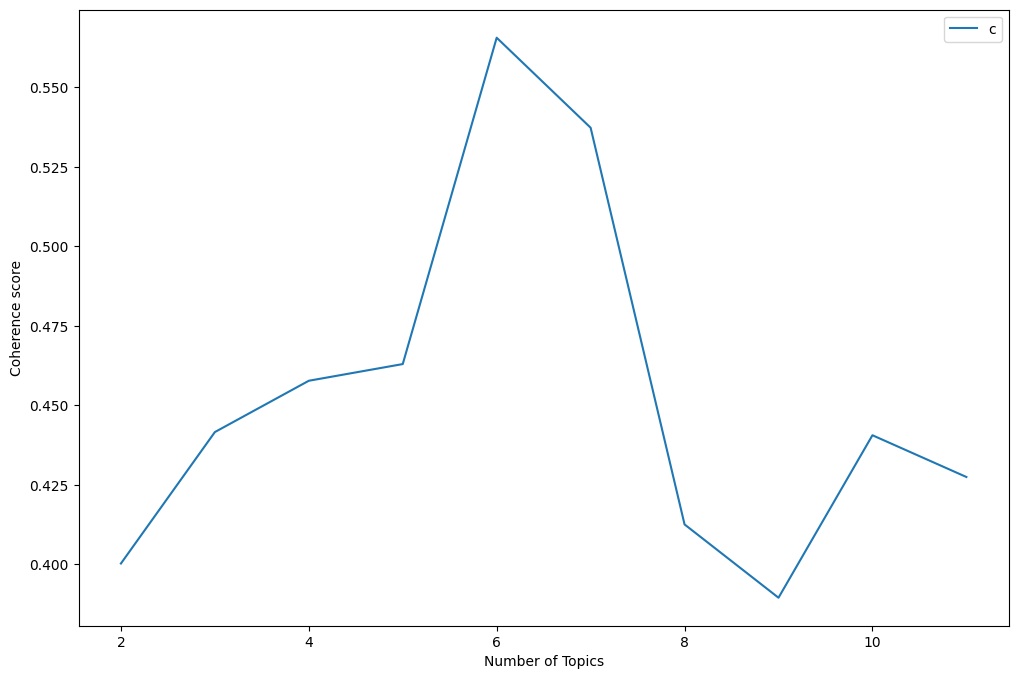

In [ ]:
get_coherence_scores(
    corpus_tfidf_fake,
    dictionary_fake,
    fake_news_text,
    min_topics=2,
    max_topics=11
)

In [ ]:
lsa_model = LsiModel(corpus_tfidf_fake, id2word=dictionary_fake, num_topics=7)


In [ ]:

lsa_model.print_topics()

[(0,
  '0.193*"trump" + 0.137*"clinton" + 0.095*"hillary" + 0.095*"obama" + 0.092*"woman" + 0.090*"president" + 0.080*"flynn" + 0.078*"republican" + 0.077*"party" + 0.076*"boiler"'),
 (1,
  '0.329*"boiler" + 0.287*"acr" + 0.247*"room" + 0.243*"pm" + 0.188*"broadcast" + 0.182*"radio" + 0.143*"animal" + 0.143*"tune" + 0.135*"jay" + 0.134*"episode"'),
 (2,
  '0.668*"flynn" + 0.187*"immunity" + 0.125*"nana" + 0.116*"mr" + 0.114*"march" + 0.094*"source" + 0.092*"russian" + 0.092*"adviser" + 0.087*"lawyer" + 0.085*"congressional"'),
 (3,
  '-0.221*"clinton" + 0.187*"school" + 0.179*"student" + -0.142*"hillary" + 0.118*"county" + -0.112*"sander" + -0.098*"woman" + 0.097*"flynn" + -0.096*"debate" + -0.089*"nominee"'),
 (4,
  '0.208*"trump" + -0.197*"email" + -0.157*"dnc" + -0.128*"clinton" + 0.120*"flynn" + 0.117*"vote" + 0.114*"cruz" + -0.112*"department" + -0.105*"rich" + 0.097*"noah"'),
 (5,
  '-0.276*"student" + -0.168*"school" + 0.134*"mccain" + 0.124*"obama" + -0.117*"trump" + 0.113*"put

# **Creating our custom Classifier**

In [ ]:
X = [" ".join(map(str, l)) for l in data['text_clean']]



In [ ]:
Y = data['fake_or_factual']



In [ ]:
countvec = CountVectorizer()



In [ ]:
countvec_fit = countvec.fit_transform(X)



In [ ]:
bag_of_words = pd.DataFrame(
    countvec_fit.toarray(),
    columns=countvec.get_feature_names_out()
)


In [ ]:

X_train, X_test, y_train, y_test = train_test_split(
    bag_of_words, Y, test_size=0.3
)


In [ ]:

lr = LogisticRegression(random_state=0).fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

accuracy_score(y_pred_lr, y_test)

0.9

In [ ]:
svm = SGDClassifier().fit(X_train, y_train)



In [ ]:
y_pred_svm = svm.predict(X_test)



In [ ]:
accuracy_score(y_pred_svm, y_test)



0.9

In [ ]:
print(classification_report(y_test, y_pred_svm))

              precision    recall  f1-score   support

Factual News       0.89      0.94      0.91        34
   Fake News       0.92      0.85      0.88        26

    accuracy                           0.90        60
   macro avg       0.90      0.89      0.90        60
weighted avg       0.90      0.90      0.90        60

